In [18]:


import polaris as po
import pandas as pd
from transformers import AutoTokenizer, EsmForSequenceClassification, EsmConfig
from transformers import TrainingArguments, Trainer
from transformers import Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from peft import get_peft_model, LoraConfig, TaskType
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch
from datasets import Dataset, DatasetDict
from transformers import DataCollatorWithPadding
import seaborn as sns
import wandb

from egfr_binder_expression.dataset import get_data

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
df = get_data()

⠼ Fetching artifact... 

2024-10-04 08:44:18.782 | INFO     | polaris._artifact:_validate_version:66 - The version of Polaris that was used to create the artifact (0.8.7.dev1+g23fd61e.d20240926) is different from the currently installed version of Polaris (0.8.6).
2024-10-04 08:44:18.783 | INFO     | polaris.mixins._checksum:verify_checksum:65 - To verify the checksum, we need to recompute it. This can be slow for large datasets.


✅ SUCCESS: Fetched artifact.
 


/home/naka/code/egfr_binder_expression/.venv/lib/python3.11/site-packages/yaspin/core.py:239: UserWarning: color, on_color and attrs are not supported when running in jupyter
  self._color = self._set_color(value) if value else value


In [22]:
df['sequence_name'].isin(['aqamar-seq2'])

0

/home/naka/code/egfr_binder_expression/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 9.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/naka/code/egfr_binder_expression/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 5.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='length', ylabel='expression'>

/home/naka/code/egfr_binder_expression/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 16.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/naka/code/egfr_binder_expression/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 5.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/naka/code/egfr_binder_expression/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 15.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


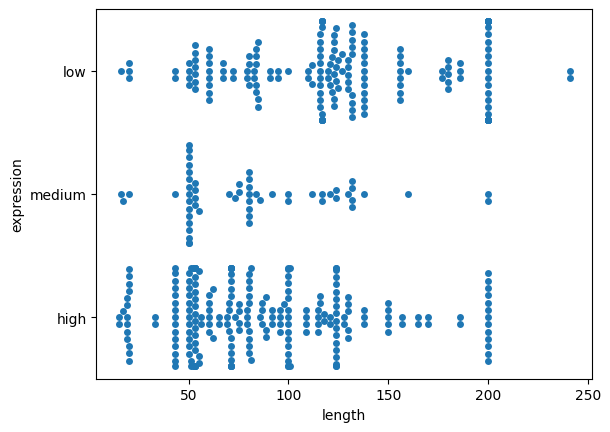

In [3]:

sns.swarmplot(df, x='length', y='expression')


In [4]:


# model_name = "facebook/esm2_t33_650M_UR50D"
model_name = "facebook/esm2_t30_150M_UR50D"

# model_name = "facebook/esm2_t6_8M_UR50D"

# Load the configuration
config = EsmConfig.from_pretrained(model_name, num_labels=3)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = EsmForSequenceClassification.from_pretrained(model_name, config=config)


/home/naka/code/egfr_binder_expression/.venv/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of EsmForSequenceClassification were not initialized from the model checkpoint at facebook/esm2_t30_150M_UR50D and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [5]:

lora_config = LoraConfig(
    r=4,  # rank of the update matrices
    lora_alpha=16,  # scaling factor
    target_modules=["query", "key", "value"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.SEQ_CLS,
    init_lora_weights=True,  # Initialize LoRA weights
)

# Apply LORA to the model
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 872,963 || all params: 149,670,367 || trainable%: 0.5833


In [17]:
df['expression']

0         low
1         low
2      medium
3      medium
4      medium
        ...  
456       low
457       low
458       low
459      high
460      high
Name: expression, Length: 461, dtype: object

In [6]:



X = df['sequence'].tolist()
y = df['expression'].tolist()

# Encode the labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)


In [7]:

# Convert your data to datasets
train_dataset = Dataset.from_dict({
    'sequence': X_train,
    'label': y_train
})
test_dataset = Dataset.from_dict({
    'sequence': X_test,
    'label': y_test
})

# Combine into a DatasetDict
dataset = DatasetDict({
    'train': train_dataset,
    'test': test_dataset
})

# Tokenization function
def tokenize_function(examples):
    return tokenizer(examples['sequence'], truncation=True, max_length=512, padding='max_length')

# Apply tokenization to the dataset
tokenized_datasets = dataset.map(tokenize_function, batched=True)

# Set the format of the datasets to PyTorch
tokenized_datasets.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])


Map: 100%|██████████| 93/93 [00:00<00:00, 8519.61 examples/s]


In [8]:

# Data collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Create DataLoaders
batch_size = 1
train_dataloader = torch.utils.data.DataLoader(
    tokenized_datasets['train'], 
    batch_size=batch_size, 
    shuffle=True, 
    collate_fn=data_collator
)
test_dataloader = torch.utils.data.DataLoader(
    tokenized_datasets['test'], 
    batch_size=batch_size, 
    collate_fn=data_collator
)

# Example of how to use the DataLoader
for batch in train_dataloader:
    print(batch.keys())
    print(f"Input IDs shape: {batch['input_ids'].shape}")
    print(f"Attention mask shape: {batch['attention_mask'].shape}")
    print(f"Labels shape: {batch['labels'].shape}")
    break

dict_keys(['input_ids', 'attention_mask', 'labels'])
Input IDs shape: torch.Size([1, 512])
Attention mask shape: torch.Size([1, 512])
Labels shape: torch.Size([1])


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report


def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted', zero_division=0)
    acc = accuracy_score(labels, preds)
    
    # Add confusion matrix
    cm = confusion_matrix(labels, preds)
    
    # Add per-class metrics
    class_report = classification_report(labels, preds, output_dict=True, zero_division=0)
    
    # Check prediction distribution
    unique, counts = np.unique(preds, return_counts=True)
    pred_distribution = dict(zip(unique.tolist(), counts.tolist()))  # Convert to regular Python types
    
    return {
        'accuracy': float(acc),
        'f1': float(f1),
        'precision': float(precision),
        'recall': float(recall),
        # 'confusion_matrix': cm.tolist(),
        # 'class_report': {k: {k2: float(v2) for k2, v2 in v.items() if isinstance(v2, (int, float))} 
        #                  for k, v in class_report.items() if isinstance(v, dict)},
        # 'prediction_distribution': pred_distribution
    }


with wandb.init(project="egfr_binder_expression"):
        
    training_args = TrainingArguments(
        output_dir="./results",
        num_train_epochs=30,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        warmup_steps=10,
        weight_decay=0.01,
        logging_dir="./logs",
        logging_steps=10,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        # Add wandb project name
        report_to="wandb",
        run_name="egfr_binder_expression",
    )

    # Create Trainer instance
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["test"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        # Add compute_metrics function
        compute_metrics=compute_metrics,
    )

    # Start training
    trainer.train()

In [ ]:
# After training, let's analyze the results
eval_results = trainer.evaluate()
print(eval_results)

# Check class distribution in the training set
train_labels = tokenized_datasets['train']['label']
unique, counts = np.unique(train_labels, return_counts=True)
print("Training set class distribution:", dict(zip(unique, counts)))

In [15]:
batch = tokenized_datasets['train'][0:4]

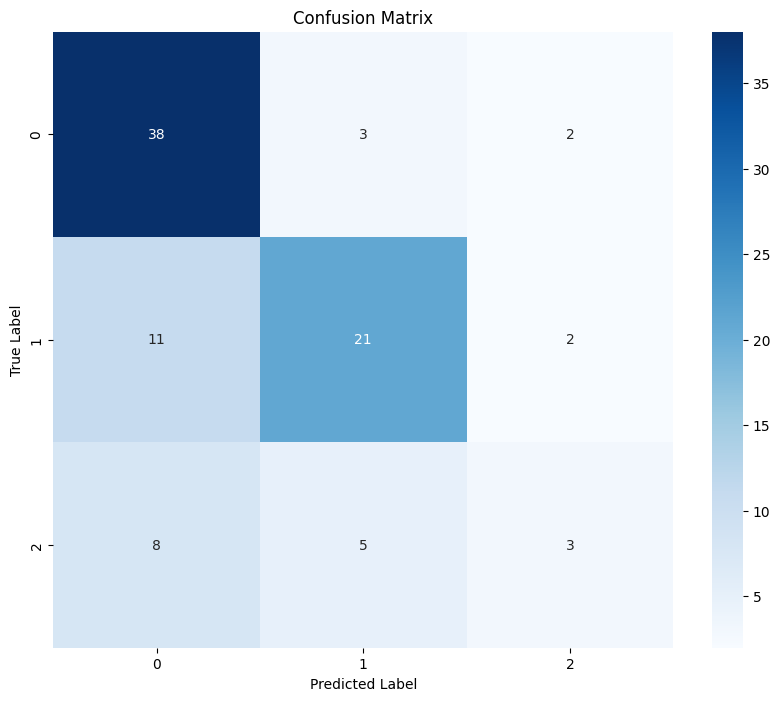

              precision    recall  f1-score   support

           0       0.67      0.88      0.76        43
           1       0.72      0.62      0.67        34
           2       0.43      0.19      0.26        16

    accuracy                           0.67        93
   macro avg       0.61      0.56      0.56        93
weighted avg       0.65      0.67      0.64        93

Prediction distribution: {0: 57, 1: 29, 2: 7}
True label distribution: {0: 43, 1: 34, 2: 16}


test/accuracy,▁
test/f1,▁
test/loss,▁
test/precision,▁
test/recall,▁
test/runtime,▁
test/samples_per_second,▁
test/steps_per_second,▁
test/accuracy,0.66667
test/f1,0.64001
test/loss,0.86025


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

with wandb.init(project="egfr_binder_expression"):
    # Get predictions
    trainer.model.eval()
    predictions = trainer.predict(tokenized_datasets['test'])

    # Compute confusion matrix
    y_true = predictions.label_ids
    y_pred = predictions.predictions.argmax(-1)
    cm = confusion_matrix(y_true, y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # Print classification report
    from sklearn.metrics import classification_report
    print(classification_report(y_true, y_pred))

    # Show prediction distribution
    unique, counts = np.unique(y_pred, return_counts=True)
    print("Prediction distribution:", dict(zip(unique, counts)))

    # Show true label distribution
    unique, counts = np.unique(y_true, return_counts=True)
    print("True label distribution:", dict(zip(unique, counts)))

In [11]:
model = model.to(device)

# scrape data

In [26]:
import requests
from bs4 import BeautifulSoup
import csv

def scrape_protein_data(url):
    response = requests.get(url)
    
    if response.status_code == 200:
        soup = BeautifulSoup(response.text, 'html.parser')
        
        data = []
        # Find the table body
        table_body = soup.select_one('div.table-responsive table tbody')
        
        if table_body:
            rows = table_body.find_all('tr')
            for row in rows:
                # Find the 5th td element (index 4) and get the text from the p tag inside the div
                sequence_cell = row.select_one('td:nth-of-type(5) div p')
                if sequence_cell:
                    sequence = sequence_cell.text.strip()
                    data.append(sequence)
        
        return data
    else:
        print(f"Failed to retrieve the webpage. Status code: {response.status_code}")
        return None

In [27]:
url = 'https://foundry.adaptyvbio.com/egfr_design_competition'
scrape_protein_data(url)

[]

In [28]:
response = requests.get(url)
    
if response.status_code == 200:
    soup = BeautifulSoup(response.text, 'html.parser')
    


In [29]:
soup

<!DOCTYPE html>
<html lang="en"><head><meta charset="utf-8"/><meta content="width=device-width, initial-scale=1" name="viewport"/><link as="font" crossorigin="" href="/_next/static/media/a34f9d1faa5f3315-s.p.woff2" rel="preload" type="font/woff2"/><link crossorigin="" data-precedence="next" href="/_next/static/css/38ca83cb8c427a32.css" rel="stylesheet"/><link as="script" crossorigin="" fetchpriority="low" href="/_next/static/chunks/webpack-3ea758946e81bac1.js" rel="preload"/><script async="" crossorigin="" src="/_next/static/chunks/fd9d1056-8d74c7046c070c4f.js"></script><script async="" crossorigin="" src="/_next/static/chunks/69-dcad20bdae00d2d8.js"></script><script async="" crossorigin="" src="/_next/static/chunks/main-app-a91ab301754ae529.js"></script><script async="" src="/_next/static/chunks/0e5ce63c-3e02ddd987664158.js"></script><script async="" src="/_next/static/chunks/877-6a7c9b1d379785f8.js"></script><script async="" src="/_next/static/chunks/618-c5f09a1d9d60bab9.js"></script

In [30]:
data = []
# Find the table body
table_body = soup.select_one('div.table-responsive table tbody')


In [32]:
table_body = soup.select_one('#radix-\:r6\:-content-results > div > div.rounded-md.mt-4.border-slate-100.bg-white.border > div > table > tbody')


In [36]:
soup.children[0]

TypeError: 'list_iterator' object is not subscriptable

In [59]:
import time
import random
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
from selenium.common.exceptions import NoSuchElementException, TimeoutException, StaleElementReferenceException, ElementClickInterceptedException

def wait_for_page_load(driver, timeout=30):
    old_page = driver.find_element(By.TAG_NAME, 'html')
    yield
    WebDriverWait(driver, timeout).until(EC.staleness_of(old_page))

def scrape_protein_data(url):
    chrome_options = Options()
    # chrome_options.add_argument("--headless")
    chrome_options.add_argument("--window-size=1920,1080")

    service = Service(ChromeDriverManager().install())
    driver = webdriver.Chrome(service=service, options=chrome_options)

    try:
        driver.get(url)
        print("Page loaded successfully")
        time.sleep(5)  # Wait for 5 seconds after initial page load

        data = []
        page = 1
        max_pages = 20  # Set the maximum number of pages to scrape

        while page <= max_pages:
            print(f"Scraping page {page}")
            table_body = WebDriverWait(driver, 20).until(
                EC.presence_of_element_located((By.CSS_SELECTOR, "#radix-\\:r6\\:-content-results > div > div.rounded-md.mt-4.border-slate-100.bg-white.border > div > table > tbody"))
            )
            print("Table body found")

            rows = table_body.find_elements(By.TAG_NAME, "tr")
            print(f"Found {len(rows)} rows")

            for row in rows:
                value_cell = row.find_elements(By.TAG_NAME, "td")[2].find_element(By.CSS_SELECTOR, "div")
                value = value_cell.text.strip() if value_cell else "N/A"

                sequence_cell = row.find_elements(By.TAG_NAME, "td")[4].find_element(By.CSS_SELECTOR, "div p")
                sequence = sequence_cell.text.strip() if sequence_cell else "N/A"

                data.append((value, sequence))

            if page == max_pages:
                print("Reached the maximum number of pages")
                break

            try:
                # Find all page number buttons
                page_buttons = driver.find_elements(By.XPATH, "//button[contains(@class, 'rounded-md') and string-length(text())=1 or string-length(text())=2]")
                current_page = max([int(btn.text) for btn in page_buttons if btn.text.isdigit()])
                print(f"Current page number: {current_page}")

                next_button = WebDriverWait(driver, 20).until(
                    EC.element_to_be_clickable((By.XPATH, "//button[text()='Next']"))
                )
                print("Next button found")
                
                # Scroll to the bottom of the page
                driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
                print("Scrolled to bottom of page")
                time.sleep(random.uniform(2, 3))  # Random wait to simulate human behavior
                
                # Try to click the button multiple times
                for attempt in range(3):
                    try:
                        with wait_for_page_load(driver, timeout=30):
                            next_button.click()
                        print(f"Clicked Next button (attempt {attempt + 1})")
                        break
                    except (ElementClickInterceptedException, StaleElementReferenceException) as e:
                        print(f"Click attempt {attempt + 1} failed: {str(e)}")
                        time.sleep(2)
                else:
                    # If all attempts fail, try JavaScript click
                    with wait_for_page_load(driver, timeout=30):
                        driver.execute_script("arguments[0].click();", next_button)
                    print("Used JavaScript to click Next button")
                
                # Wait for the page to update
                time.sleep(5)  # Wait for 5 seconds after clicking Next
                
                # Check if the page number has increased
                new_page_buttons = driver.find_elements(By.XPATH, "//button[contains(@class, 'rounded-md') and string-length(text())=1 or string-length(text())=2]")
                new_page = max([int(btn.text) for btn in new_page_buttons if btn.text.isdigit()])
                if new_page <= current_page:
                    print("Page number did not increase, might have reached the last page")
                    break
                
                print(f"Successfully moved to page {new_page}")
                page = new_page
            except Exception as e:
                print(f"Error occurred: {str(e)}")
                break

        return data

    finally:
        driver.quit()

# Test the function
url = 'https://foundry.adaptyvbio.com/egfr_design_competition'
results = scrape_protein_data(url)

if results:
    print(f"Number of entries found: {len(results)}")
    print("First few entries (value, sequence):")
    for value, seq in results[:5]:
        print(f"Value: {value}")
        print(f"Sequence: {seq}")
        print("---")
else:
    print("No data was scraped.")

Page loaded successfully
Scraping page 1
Table body found
Found 10 rows
Error occurred: max() arg is an empty sequence
Number of entries found: 10
First few entries (value, sequence):
Value: Cetuximab_scFv
Sequence: Low
---
Value: ahmedsameh-Q3
Sequence: Medium
---
Value: ahmedsameh-yy2
Sequence: Medium
---
Value: martin.pacesa-EGFR_l138_s90285_mpnn2
Sequence: High
---
Value: x.rustamov-m_18_41
Sequence: High
---


In [53]:

# Test the function
url = 'https://foundry.adaptyvbio.com/egfr_design_competition'
sequences = scrape_protein_data(url)

Scraping page 1
Reached last page (no change in content)


In [54]:
sequences

[('Cetuximab_scFv', 'Low'),
 ('ahmedsameh-Q3', 'Medium'),
 ('ahmedsameh-yy2', 'Medium'),
 ('martin.pacesa-EGFR_l138_s90285_mpnn2', 'High'),
 ('x.rustamov-m_18_41', 'High'),
 ('adrian.tripp-egfr_cetuxi_0133_0002_A', 'High'),
 ('alecl-Sequence1', 'High'),
 ('alan.blakely-design:5 n:6|mpnn:1.247|plddt:0.825|ptm:0.709|pae:10.151|rmsd:3.535',
  'High'),
 ('alex.naka-158511', 'Medium'),
 ('alex.naka-dda1c8', 'Medium')]